In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.optim as optim
import torch.nn as nn
import skfuzzy as fuzz
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from ANFISpy import ANFIS, LSTMANFIS
from ANFISpy import HamacherAND, ProdAND

In [2]:
project_root = Path.cwd().parent  # Go up one level from /notebooks/ to the project root
data_path = project_root / "Data" / "Processed Data" / "AirQualityUCI_cleaned.csv"

# --- Load the Dataset ---
df = pd.read_csv(data_path)

# Features 
X = df[['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 
        'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]

# Target 
y = df['C6H6(GT)']  # benzene concentration

# --- Preview the Data ---
df.head()

,Date,Time,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,1360.00,11.881723,1045.50,1056.25,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,1292.25,9.397165,954.75,1173.75,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,1402.00,8.997817,939.25,1140.00,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,1375.50,9.228796,948.25,1092.00,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1272.25,6.518224,835.50,1205.00,1490.00,1110.00,11.15,59.575001,0.788794


In [3]:
SEQ_LEN = 10         
BATCH_SIZE = 16       
SEED = 42
SELECTED_FEATURES = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 
        'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']  # only 3 features for now
TARGET = ['C6H6(GT)']

In [4]:
# --- Select only chosen features ---
X_sel = X[SELECTED_FEATURES].copy()

# Handle target depending on y's structure
if isinstance(y, pd.DataFrame):
    # Case 1: y is a DataFrame
    if TARGET[0] in y.columns:
        y_sel = y[TARGET[0]].copy()
    else:
        # Sometimes the target is stored in X instead of y
        y_sel = X[TARGET[0]].copy()
else:
    # Case 2: y is a Series or array
    y_sel = pd.Series(y).copy()

In [5]:
# --- Train / Validation / Test Split ---
x_train, x_temp, y_train, y_temp = train_test_split(X_sel, y_sel, test_size=0.4, random_state=SEED)
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=SEED)

# --- Scale using only training data to avoid data leakage ---
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val   = scaler.transform(x_val)
x_test  = scaler.transform(x_test)

In [6]:
# --- Convert targets to numpy arrays ---
y_train = y_train.to_numpy().reshape(-1, 1)
y_val   = y_val.to_numpy().reshape(-1, 1)
y_test  = y_test.to_numpy().reshape(-1, 1)

In [7]:
x_train = torch.tensor(x_train, dtype=torch.float32) 
y_train = torch.tensor(y_train, dtype=torch.float32) 
x_test = torch.tensor(x_test, dtype=torch.float32) 
y_test = torch.tensor(y_test, dtype=torch.float32) 
x_val = torch.tensor(x_val, dtype=torch.float32) 
y_val = torch.tensor(y_val, dtype=torch.float32)

In [8]:
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)



train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

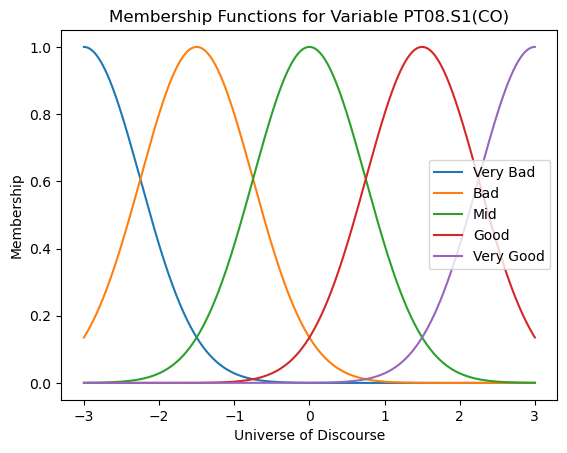

In [9]:
n_inputs = 8                     
mf_per_input = 5                 
mf_names = ['Very Bad', 'Bad', 'Mid', 'Good', 'Very Good']

FEATURES = ['PT08.S1(CO)', 'T', 'RH']
TARGET = ['C6H6(GT)']

and_op = HamacherAND(r=1)

variables = {
    'inputs': {
        'n_sets': [mf_per_input] * n_inputs,
        'uod': [(-3, 3)] * n_inputs, 
        'var_names': FEATURES,
        'mf_names': [list(mf_names) for _ in range(n_inputs)],
    },
    'output': {
        'var_names': TARGET[0],
        'n_classes': 1,
    },
}

anfis = ANFIS(
    variables=variables,
    mf_shape='gaussian',
    and_operator=and_op
)

# --- Test plotting to confirm setup ---
fig, ax = anfis.plot_var(FEATURES[0])
plt.show()

In [10]:
criterion = nn.MSELoss()
optimizer = optim.Adam(anfis.parameters(), lr=0.001)

In [11]:
epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    anfis.train()
    train_loss = 0.0
    
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = anfis(x_batch)
        loss = criterion(y_pred, y_batch.flatten())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    anfis.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            y_pred = anfis(x_batch)
            loss = criterion(y_pred, y_batch.flatten())
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    if epoch % 10 == 9:
        print(f'Epoch {epoch+1}/{epochs}: train_loss: {train_loss:.4f} validation_loss {val_loss:.4f}')

Epoch 10/100: train_loss: 8.8268 validation_loss 9.8472
Epoch 20/100: train_loss: 4.5121 validation_loss 5.1580
Epoch 30/100: train_loss: 3.0081 validation_loss 3.6654
Epoch 40/100: train_loss: 2.2641 validation_loss 2.8508
Epoch 50/100: train_loss: 1.7158 validation_loss 2.2397
Epoch 60/100: train_loss: 1.3550 validation_loss 1.8240
Epoch 70/100: train_loss: 1.1034 validation_loss 1.4833
Epoch 80/100: train_loss: 0.8777 validation_loss 1.2304
Epoch 90/100: train_loss: 0.6953 validation_loss 1.0561
Epoch 100/100: train_loss: 0.5631 validation_loss 0.8362


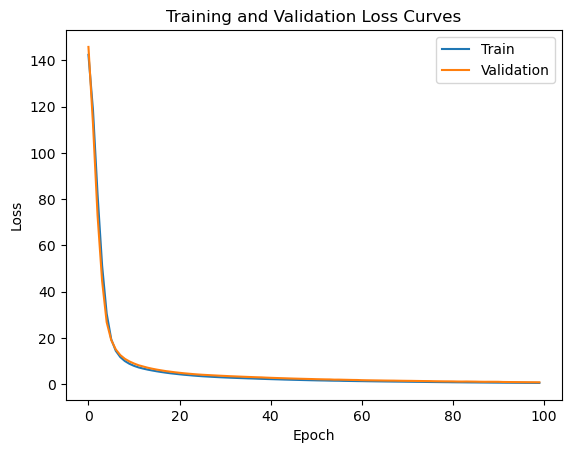

In [12]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss Curves')
plt.show()

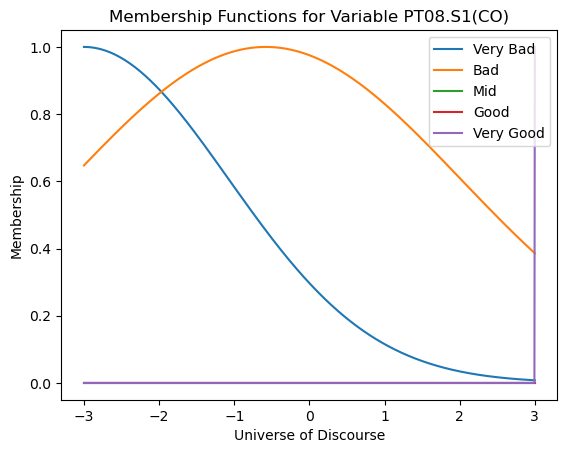

In [13]:
fig, ax = anfis.plot_var(FEATURES[0])
plt.show()

RMSE: 0.7982


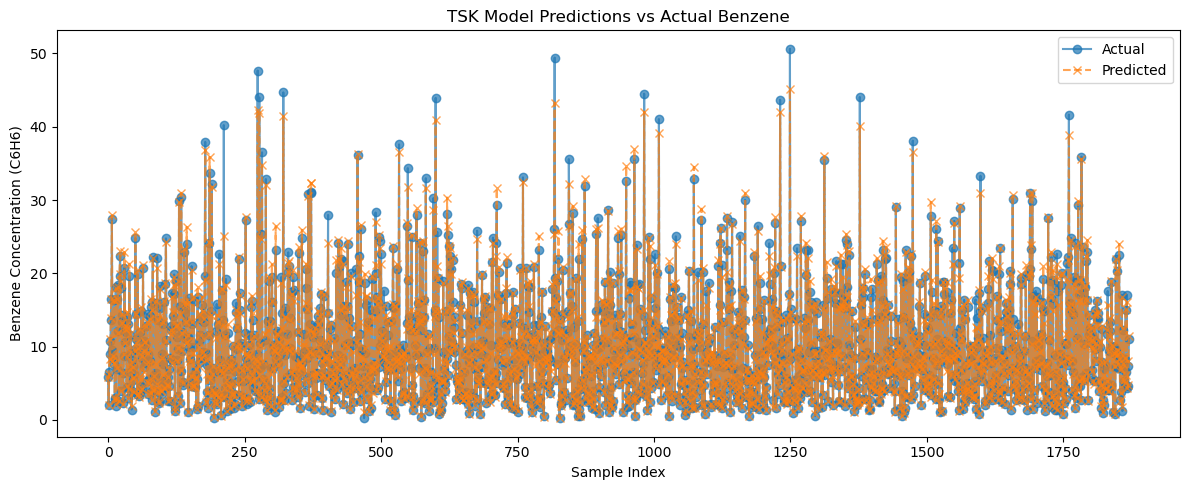

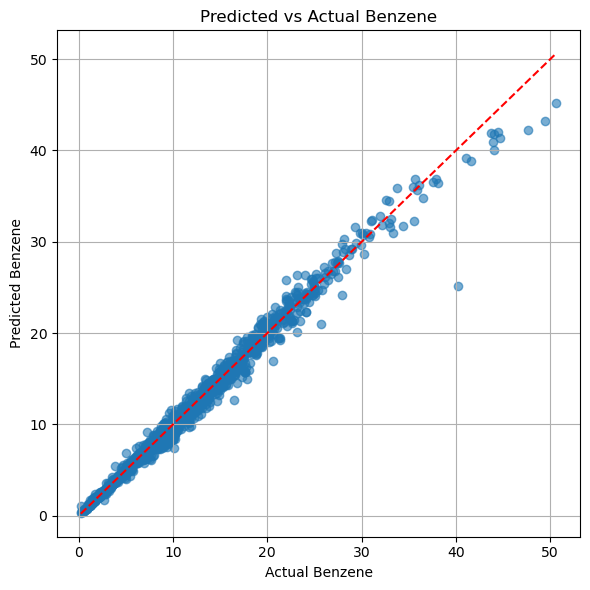

MSE ANFIS: 0.6371


In [14]:
# --- Evaluate ANFIS on test data ---
anfis.eval()
y_preds = []
y_trues = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        y_pred = anfis(x_batch)
        y_preds.append(y_pred)
        y_trues.append(y_batch.flatten())

# Concatenate all batches
y_pred_ANFIS = torch.cat(y_preds)
y_true = torch.cat(y_trues)

# --- Compute RMSE ---
rmse = torch.sqrt(torch.mean((y_pred_ANFIS - y_true) ** 2))
print(f"RMSE: {rmse.item():.4f}")

# --- Convert to NumPy for plotting ---
y_true_np = y_true.detach().numpy()
y_pred_np = y_pred_ANFIS.detach().numpy()

# --- Line plot: Actual vs Predicted ---
plt.figure(figsize=(12, 5))
plt.plot(y_true_np, label="Actual", marker='o', linestyle='-', alpha=0.7)
plt.plot(y_pred_np, label="Predicted", marker='x', linestyle='--', alpha=0.7)
plt.title("TSK Model Predictions vs Actual Benzene")
plt.xlabel("Sample Index")
plt.ylabel("Benzene Concentration (C6H6)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Scatter plot: Predicted vs Actual ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true_np, y_pred_np, alpha=0.6)
plt.plot([y_true_np.min(), y_true_np.max()], [y_true_np.min(), y_true_np.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Benzene")
plt.ylabel("Predicted Benzene")
plt.title("Predicted vs Actual Benzene")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Optional: Compute MSE for reference ---
mse_ANFIS = mean_squared_error(y_true_np, y_pred_np)
print(f"MSE ANFIS: {mse_ANFIS:.4f}")

In [15]:
# Define paths
project_root = Path.cwd().parent
trained_models_dir = project_root / "Trained_models"
trained_models_dir.mkdir(exist_ok=True)
save_path = trained_models_dir / "ANFISpy_Model.pth"

# Save state dict
torch.save(anfis.state_dict(), save_path)